In [40]:
# 1. Import Libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [41]:
# 2. Load Dataset
data = load_iris()

# 3. Creating dataset
df = pd.DataFrame(data["data"],columns=data.feature_names)
df["target"]=data.target

In [18]:
print(df)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target  
0         0  

In [19]:
# 4. Understanding the dataset

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None


In [20]:
print(df.shape)

(150, 5)


In [21]:
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [22]:
print(df.tail())

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target  
145       2  
146       2  
147       2  
148       2  
149       2  


In [23]:
print(df.target.unique())

[0 1 2]


In [24]:
print(df.target.nunique())

3


In [25]:
print(df["target"].value_counts())

target
0    50
1    50
2    50
Name: count, dtype: int64


In [26]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [27]:
# 5. Separate Features

X = df.drop("target",axis=1)
y = df["target"]

In [42]:
# 6. Split dataset into training and testing 

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [43]:
# 7. Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [44]:
# 8. Build multiclass ANN

model = Sequential([
    Input(shape=(4,)),
    Dense(32,activation="relu"),
    Dropout(0.2),
    Dense(16,activation="relu"),
    Dropout(0.2),
    Dense(3)
])

In [45]:
# 9. Model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 32)                  │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 739 (2.89 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
#10. Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [47]:
#11. Early Stopping
early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
)

In [48]:
#12. Train model
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3021 - loss: 5.5903 - val_accuracy: 0.5000 - val_loss: 3.8497
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3438 - loss: 5.2681 - val_accuracy: 0.5417 - val_loss: 2.7848
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3021 - loss: 3.9963 - val_accuracy: 0.6667 - val_loss: 1.6611
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3229 - loss: 3.7821 - val_accuracy: 0.6667 - val_loss: 1.5018
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3854 - loss: 3.1463 - val_accuracy: 0.5833 - val_loss: 0.8926
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3750 - loss: 3.2131 - val_accuracy: 0.5000 - val_loss: 0.8273
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4375 - loss: 2.2034 - val_accuracy: 0.4583 - val_loss: 0.7845
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4792 - loss: 1.6672 - val_accuracy: 0.5417 - val_loss: 0.75

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8021 - loss: 0.6833 - val_accuracy: 0.7500 - val_loss: 0.4323
Epoch 53/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8646 - loss: 0.4744 - val_accuracy: 0.7917 - val_loss: 0.4290
Epoch 54/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8438 - loss: 0.3989 - val_accuracy: 0.7917 - val_loss: 0.4255
Epoch 55/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8438 - loss: 0.3857 - val_accuracy: 0.7917 - val_loss: 0.4220
Epoch 56/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8854 - loss: 0.6425 - val_accuracy: 0.7917 - val_loss: 0.4177
Epoch 57/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8854 - loss: 0.4289 - val_accuracy: 0.7917 - val_loss: 0.4176
Epoch 58/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8958 - loss: 0.3414 - val_accuracy: 0.7500 - val_loss: 0.4204
Epoch 59/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9167 - loss: 0.5441 - val_accuracy: 0.7500 - val_loss: 0.4213
Epoch

In [49]:
#13. Evaluation
test_loss, accuracy = model.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9667 - loss: 0.2362


In [50]:
print("Test Loss", test_loss)

Test Loss 0.2361573725938797


In [52]:
print("Test Accuracy", accuracy)

Test Accuracy 0.9666666388511658


In [53]:
y_probability = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


In [54]:
print("\nFirst 5 Probabilities:")
print(y_probability[:5])


First 5 Probabilities:
[[-0.1938848   0.19110483  0.05158363]
 [ 0.48683566 -0.37662193 -0.5038517 ]
 [-1.018855    0.62330437  0.76348233]
 [-0.1942821   0.14153436  0.09058664]
 [-0.41293108  0.44141048  0.23758659]]


In [56]:
import numpy as np

In [57]:
y_pred = np.argmax(
    y_probability,
    axis=1
)

In [58]:
print(y_pred[:5])


[1 0 2 1 1]


In [59]:
print(y_test[:5])

73     1
18     0
118    2
78     1
76     1
Name: target, dtype: int64


In [60]:
cm = confusion_matrix(
    y_test,
    y_pred
)

In [61]:
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


In [62]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)



Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



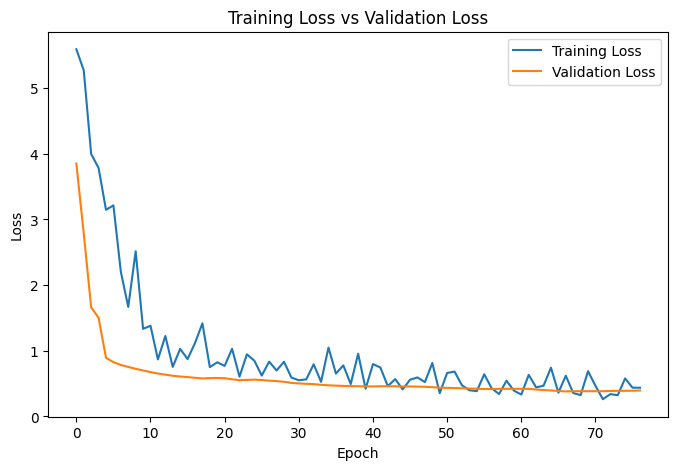

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()

plt.show()


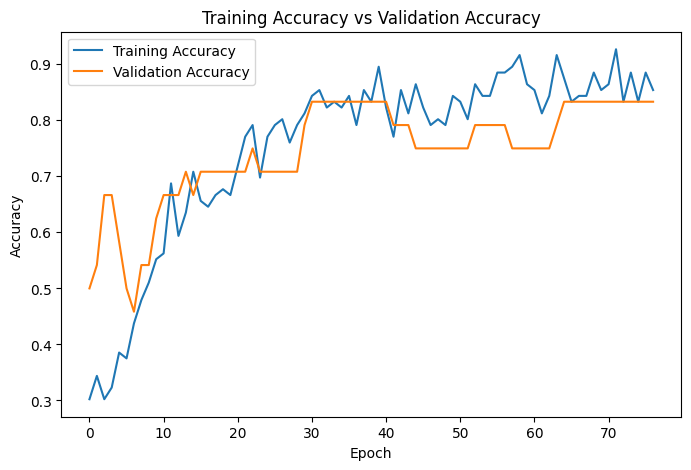

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Validation Accuracy")
plt.legend()

plt.show()